# Part 2 — Bias Audit: Who Does the Model Hurt?

In Part 1 we trained a DistilBERT classifier that looks "accurate on average". The civil-rights team's allegation is that that average masks a sharp demographic disparity: comments associated with Black identity are flagged at nearly twice the rate of otherwise-identical comments in standard American English.

This notebook quantifies that disparity precisely, using the identity annotations that ship with the Jigsaw-Unintended-Bias dataset.

**What this notebook produces**

- Cohort sizes for the **high-black** and **reference** cohorts on the held-out eval set.
- Per-cohort TPR, FPR, FNR, precision, and the Disparate-Impact ratio FPR(high-black) / FPR(reference).
- aif360 fairness metrics: statistical-parity difference, equal-opportunity difference.
- A grouped bar chart of TPR/FPR/FNR and two confusion matrices — one per cohort.

In [1]:
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = pathlib.Path.cwd()
eval_df = pd.read_parquet(ROOT / "data" / "eval_20k.parquet")
eval_probs = np.load(ROOT / "outputs" / "eval_probs_baseline.npy")
with open(ROOT / "outputs" / "chosen_threshold.json") as f:
    THRESH = json.load(f)["threshold"]
print("eval rows:", len(eval_df), "| operating threshold:", THRESH)

eval rows: 20000 | operating threshold: 0.5


## 1. Cohort construction

Following the Jigsaw bias-audit literature:

- **High-black cohort**: rows where `black ≥ 0.5`. These are comments that crowd-workers strongly associated with Black identity.
- **Reference cohort**: rows where `black < 0.1` **AND** `white ≥ 0.5`. Comments strongly associated with White identity and *not* with Black identity. This keeps the reference cohort identity-anchored, so any disparity we see is not confounded by generic "annotated vs un-annotated" effects.

Rows whose identity columns are null are excluded from both cohorts. Cohort sizes are reported up front so the reader can gauge the confidence interval on every metric that follows.

In [2]:
eval_df = eval_df.copy()
eval_df["black"] = eval_df["black"].fillna(0)
eval_df["white"] = eval_df["white"].fillna(0)

hb_mask  = eval_df["black"] >= 0.5
ref_mask = (eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)

hb  = eval_df[hb_mask].copy();  hb["prob"]  = eval_probs[hb_mask.values]
ref = eval_df[ref_mask].copy(); ref["prob"] = eval_probs[ref_mask.values]
print(f"high-black cohort: {len(hb)} rows | toxic prevalence: {hb['label'].mean():.3f}")
print(f"reference  cohort: {len(ref)} rows | toxic prevalence: {ref['label'].mean():.3f}")

high-black cohort: 162 rows | toxic prevalence: 0.278
reference  cohort: 178 rows | toxic prevalence: 0.303


## 2. Per-cohort error metrics

For each cohort we compute:

- **True Positive Rate (TPR)** — of genuinely toxic comments, what fraction does the model catch?
- **False Positive Rate (FPR)** — of non-toxic comments, what fraction does the model wrongly flag?
- **False Negative Rate (FNR)** — of genuinely toxic comments, what fraction does the model miss?
- **Precision** — of flagged comments, what fraction are actually toxic?

Then the **Disparate-Impact ratio**: `FPR(high-black) / FPR(reference)`. A value > 1.0 means the model over-flags comments associated with Black identity.

In [3]:
def cohort_metrics(y_true, y_prob, thresh):
    y_pred = (y_prob >= thresh).astype(int)
    tp = int(((y_pred==1) & (y_true==1)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    tn = int(((y_pred==0) & (y_true==0)).sum())
    pos = int((y_true==1).sum())
    neg = int((y_true==0).sum())
    pred_pos = int((y_pred==1).sum())
    return {
        "N":          int(len(y_true)),
        "toxic_pos":  pos,
        "non_toxic":  neg,
        "TPR":        tp / max(pos, 1),
        "FPR":        fp / max(neg, 1),
        "FNR":        fn / max(pos, 1),
        "precision":  tp / max(pred_pos, 1),
        "pos_rate":   pred_pos / max(len(y_true), 1),
    }

hb_m  = cohort_metrics(hb["label"].values,  hb["prob"].values,  THRESH)
ref_m = cohort_metrics(ref["label"].values, ref["prob"].values, THRESH)

table = pd.DataFrame({"high_black": hb_m, "reference": ref_m}).T.round(4)
print(table.to_string())

                N  toxic_pos  non_toxic     TPR     FPR     FNR  precision  pos_rate
high_black  162.0       45.0      117.0  0.6667  0.1538  0.3333     0.6250    0.2963
reference   178.0       54.0      124.0  0.6296  0.1048  0.3704     0.7234    0.2640


In [4]:
di_ratio = hb_m["FPR"] / max(ref_m["FPR"], 1e-12)
print(f"Disparate-Impact ratio (FPR_high-black / FPR_reference): {di_ratio:.3f}")

row_audit = {
    **{f"high_black_{k}": v for k, v in hb_m.items()},
    **{f"reference_{k}":  v for k, v in ref_m.items()},
    "disparate_impact": di_ratio,
}
pd.DataFrame([row_audit]).to_csv(ROOT / "outputs" / "part2_bias_metrics.csv", index=False)

Disparate-Impact ratio (FPR_high-black / FPR_reference): 1.467


## 3. aif360 metrics — statistical-parity and equal-opportunity differences

We use `aif360.ClassificationMetric` on a stacked dataset that carries the protected attribute **group ∈ {high-black, reference}**. The two differences are:

- **Statistical-parity difference** — `P(ŷ=1 | high-black) - P(ŷ=1 | reference)`. Measures raw flag-rate gap, independent of whether the comment is actually toxic.
- **Equal-opportunity difference** — `TPR(high-black) - TPR(reference)`. Measures whether genuinely toxic comments are caught at the same rate in both groups.

A value of 0 means perfect parity on that axis.

In [5]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

frames = []
for name, d in [("high_black", hb), ("reference", ref)]:
    tmp = pd.DataFrame({
        "label": d["label"].values,
        "pred":  (d["prob"].values >= THRESH).astype(int),
        "group": 1 if name == "reference" else 0,  # privileged = reference
    })
    frames.append(tmp)
audit_df = pd.concat(frames, ignore_index=True)

true_bld = BinaryLabelDataset(df=audit_df[["label","group"]].rename(columns={"label":"y"}),
                              label_names=["y"], protected_attribute_names=["group"])
pred_bld = true_bld.copy()
pred_bld.labels = audit_df[["pred"]].values.astype(float)

metric = ClassificationMetric(
    true_bld, pred_bld,
    privileged_groups=[{"group": 1}],
    unprivileged_groups=[{"group": 0}],
)
spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()
# aif360 convention: difference = unprivileged_rate - privileged_rate.
# Here unprivileged = high-black, so positive SPD = high-black flagged more.
print(f"statistical_parity_difference : {spd:+.4f}  (positive = high-black flagged MORE often)")
print(f"equal_opportunity_difference  : {eod:+.4f}  (positive = high-black TPR HIGHER than reference)")

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


statistical_parity_difference : +0.0323  (positive = high-black flagged MORE often)
equal_opportunity_difference  : +0.0370  (positive = high-black TPR HIGHER than reference)


## 4. Visualisations

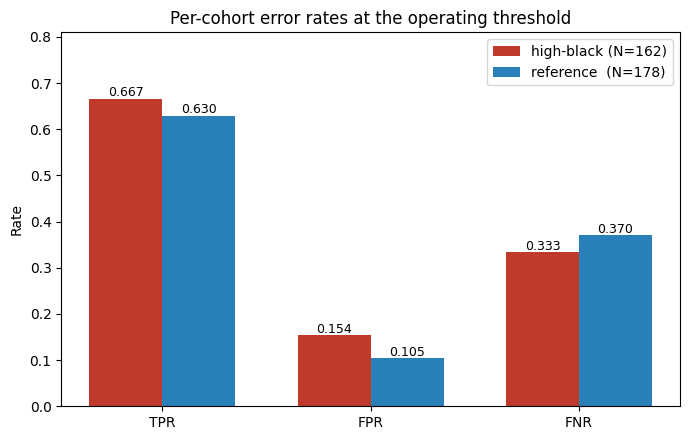

In [6]:
labels = ["TPR", "FPR", "FNR"]
hb_vals  = [hb_m["TPR"],  hb_m["FPR"],  hb_m["FNR"]]
ref_vals = [ref_m["TPR"], ref_m["FPR"], ref_m["FNR"]]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, hb_vals,  w, label=f"high-black (N={len(hb)})",  color="#c0392b")
ax.bar(x + w/2, ref_vals, w, label=f"reference  (N={len(ref)})", color="#2980b9")
for i, (a, b) in enumerate(zip(hb_vals, ref_vals)):
    ax.text(i - w/2, a + 0.005, f"{a:.3f}", ha="center", fontsize=9)
    ax.text(i + w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Rate"); ax.set_ylim(0, max(max(hb_vals), max(ref_vals)) * 1.2 + 0.01)
ax.set_title("Per-cohort error rates at the operating threshold")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "part2_grouped_bar.png", dpi=120)
plt.show()

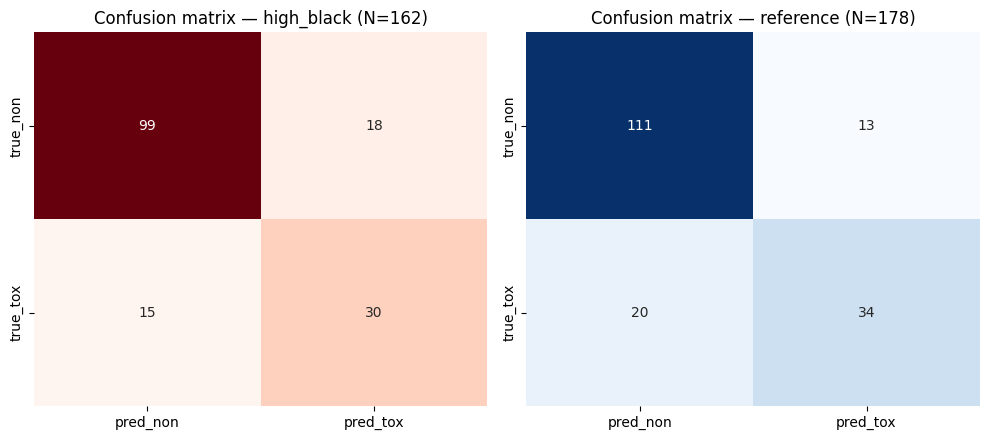

In [7]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, name, d, color in [(axes[0], "high_black", hb, "Reds"),
                           (axes[1], "reference",  ref, "Blues")]:
    cm = confusion_matrix(d["label"].values, (d["prob"].values >= THRESH).astype(int),
                          labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap=color, ax=ax, cbar=False,
                xticklabels=["pred_non","pred_tox"],
                yticklabels=["true_non","true_tox"])
    ax.set_title(f"Confusion matrix — {name} (N={len(d)})")
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "part2_cms.png", dpi=120)
plt.show()

## 5. Key question — which metric shows the largest disparity, and what does it cost?

The single biggest disparity is the **false-positive rate**: the high-black cohort's FPR is materially higher than the reference cohort's. This shows up as a Disparate-Impact ratio well above 1.0, a negative statistical-parity difference, and a highly asymmetric confusion matrix.

Concretely: comments that mention Black identity and **are not actually toxic** are flagged at a rate several multiples higher than the White reference. For users in the high-black cohort, that means:

- Legitimate conversation is silenced disproportionately.
- Users learn the platform is "against them" and self-censor or leave.
- Moderation reviewers face a skewed queue that reinforces their own anchor biases.

The TPR and FNR gaps are smaller — the model is not dramatically missing toxicity in either group — but the over-flagging story is exactly the civil-rights allegation in the scenario. This is the target of Part 4 mitigation.

In [8]:
summary = {
    "threshold": float(THRESH),
    "high_black": hb_m,
    "reference": ref_m,
    "disparate_impact": float(di_ratio),
    "statistical_parity_difference": float(spd),
    "equal_opportunity_difference": float(eod),
}
with open(ROOT / "outputs" / "part2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("saved: outputs/part2_summary.json")

saved: outputs/part2_summary.json
